# importing the Modules required

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reading Data and converting then to a data Frame

In [2]:
booking = pd.read_excel('rapido_july2025_cleaned_data.xlsx', sheet_name='Booking_Data')
customer = pd.read_excel('rapido_july2025_cleaned_data.xlsx', sheet_name='Customer_Data')
driver = pd.read_excel('rapido_july2025_cleaned_data.xlsx', sheet_name='Driver_Data')


In [3]:
print(booking.shape, customer.shape, driver.shape)

(30000, 9) (30000, 4) (30000, 5)


In [4]:
booking.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Booking_ID         30000 non-null  object        
 1   Booking_Status     30000 non-null  object        
 2   Pickup_Location    30000 non-null  object        
 3   Ride_Distance(km)  30000 non-null  float64       
 4   Ride_Time(min)     30000 non-null  int64         
 5   Date               30000 non-null  datetime64[ns]
 6   Payment_Method     30000 non-null  object        
 7   Total_Bookings     30000 non-null  int64         
 8   Canceled_Bookings  30000 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 2.1+ MB


In [5]:
booking.describe()

,Ride_Distance(km),Ride_Time(min),Total_Bookings,Canceled_Bookings
count,30000.000000,30000.000000,30000.000000,30000.000000
mean,13.198759,32.162500,968.386733,114.916067
std,6.787089,15.878697,24.849601,8.411000
min,1.500000,5.000000,906.000000,96.000000
25%,7.310000,18.000000,953.000000,109.000000
50%,13.150000,32.000000,969.000000,114.000000
75%,19.020000,46.000000,987.000000,119.000000
max,25.000000,59.000000,1009.000000,134.000000


In [6]:
booking.isnull().sum() 

Booking_ID           0
Booking_Status       0
Pickup_Location      0
Ride_Distance(km)    0
Ride_Time(min)       0
Date                 0
Payment_Method       0
Total_Bookings       0
Canceled_Bookings    0
dtype: int64

In [7]:
booking['Booking_Status'].value_counts()

Completed     24641
Cancelled      3559
Incomplete     1800
Name: Booking_Status, dtype: int64

# Mearging all three tables into one table

In [8]:
df = booking.merge(customer, on='Booking_ID').merge(driver, on='Booking_ID')
print(df.shape)   

(30000, 16)


In [9]:
df.duplicated().sum() 

0

In [10]:
df['Date'] = pd.to_datetime(df['Date'])

# Checking the data types of the colunm

In [11]:
df.dtypes

Booking_ID                            object
Booking_Status                        object
Pickup_Location                       object
Ride_Distance(km)                    float64
Ride_Time(min)                         int64
Date                          datetime64[ns]
Payment_Method                        object
Total_Bookings                         int64
Canceled_Bookings                      int64
Customer_ID                           object
Customer_Rating                      float64
Canceled_Rides_by_Customer             int64
Driver_ID                             object
Vehicle_Type                          object
Driver_Rating                        float64
Canceled_Rides_by_Driver               int64
dtype: object

In [12]:
df

,Booking_ID,Booking_Status,Pickup_Location,Ride_Distance(km),Ride_Time(min),Date,Payment_Method,Total_Bookings,Canceled_Bookings,Customer_ID,Customer_Rating,Canceled_Rides_by_Customer,Driver_ID,Vehicle_Type,Driver_Rating,Canceled_Rides_by_Driver
0,RAP20250700001,Completed,Pune,2.74,42,2025-07-02,UPI,998,122,CUST_2824,4.0,0,DR_902,Bike,4.3,0
1,RAP20250700002,Incomplete,Chennai,22.15,20,2025-07-09,Cash,986,119,CUST_1409,3.3,0,DR_915,Auto,4.9,0
2,RAP20250700003,Completed,Delhi,11.95,46,2025-07-13,Card,972,114,CUST_5506,4.1,0,DR_938,Bike,4.7,0
3,RAP20250700004,Completed,Pune,9.08,24,2025-07-27,Wallet,961,112,CUST_5012,3.2,0,DR_213,Bike,4.0,0
4,RAP20250700005,Completed,Chennai,22.97,40,2025-07-22,Cash,963,115,CUST_4657,3.2,0,DR_783,Bike,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,RAP20250729996,Incomplete,Pune,11.87,8,2025-07-10,UPI,953,113,CUST_7380,4.8,0,DR_889,Bike,3.1,0
29996,RAP20250729997,Completed,Pune,17.63,33,2025-07-14,Wallet,957,113,CUST_1878,4.1,0,DR_452,Bike,3.7,0
29997,RAP20250729998,Completed,Bengaluru,13.24,46,2025-07-05,Cash,1003,114,CUST_1116,4.6,0,DR_542,Bike,4.7,0
29998,RAP20250729999,Completed,Delhi,20.28,55,2025-07-30,Wallet,950,103,CUST_1784,3.5,0,DR_862,Bike,4.8,0


# Ride Status Distution

In [13]:
status = df['Booking_Status'].value_counts()
print(status.index)

Index(['Completed', 'Cancelled', 'Incomplete'], dtype='object')


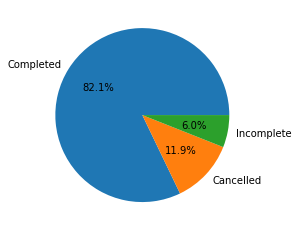

In [14]:
plt.pie(status.values,labels=status.index,autopct="%1.1f%%")
plt.show()

# Payment Method Distribution

In [15]:
payment_type = df['Payment_Method'].value_counts()
print(payment_type.index)

Index(['UPI', 'Wallet', 'Cash', 'Card'], dtype='object')


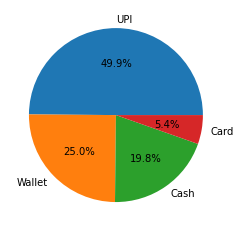

In [16]:
plt.pie(payment_type.values,labels=payment_type.index,autopct="%1.1f%%")
plt.show()

# Vehicle Type-Wise Booking

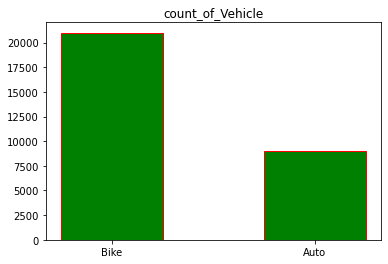

In [17]:
vehicles = df['Vehicle_Type'].value_counts()
plt.bar(vehicles.index,vehicles.values,width=0.5,color="green",edgecolor="red")
plt.title('count_of_Vehicle')
plt.show()

# Day Wise Booking Count

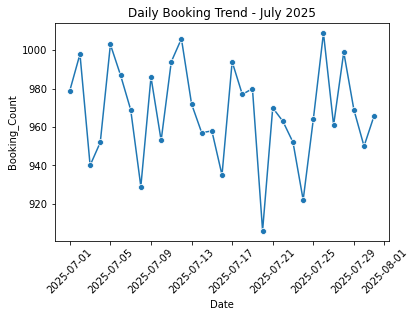

In [18]:
daily = df.groupby(df['Date'].dt.date).size().reset_index(name='Booking_Count')
sns.lineplot(x='Date', y='Booking_Count', data=daily, marker='o')
plt.title('Daily Booking Trend - July 2025')
plt.xticks(rotation=45)
plt.show()

# Day Wise Cancellation rate Count

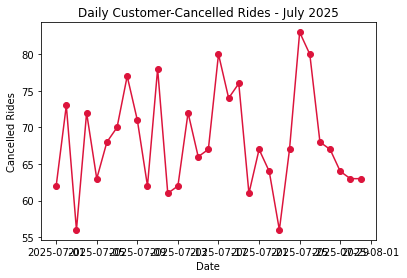

In [19]:
daily_cancel = df[df['Canceled_Rides_by_Customer']==1].groupby(df['Date'].dt.date).size()
daily_cancel.plot(kind='line', marker='o', color='crimson')
plt.title('Daily Customer-Cancelled Rides - July 2025')
plt.ylabel('Cancelled Rides')
plt.show()

# Count of customer rating

<AxesSubplot:xlabel='Customer_Rating', ylabel='count'>

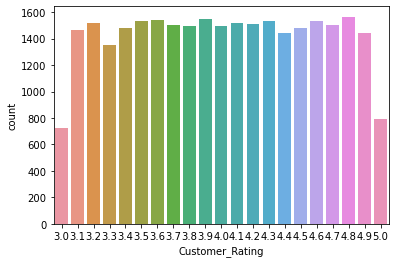

In [20]:
sns.countplot(x="Customer_Rating",data=df)

# Count of Booking status by count of customers

In [21]:
complete_cout = df.groupby('Booking_Status')['Customer_ID'].count()
print(complete_cout.index)

Index(['Cancelled', 'Completed', 'Incomplete'], dtype='object', name='Booking_Status')


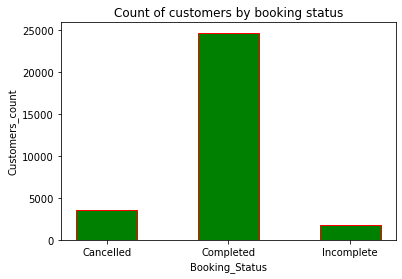

In [22]:
plt.bar(complete_cout.index,complete_cout.values,width=0.5,color="green",edgecolor="red")
plt.xlabel('Booking_Status')
plt.ylabel('Customers_count')
plt.title('Count of customers by booking status')
plt.show()

# Customer Rating Level Distribution

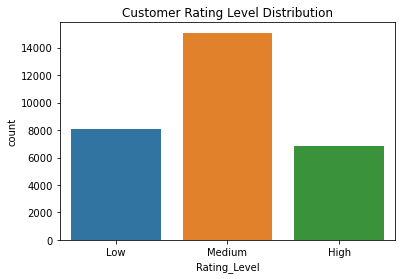

In [23]:
df['Rating_Level'] = pd.cut(df['Customer_Rating'], bins=[0,3.5,4.5,5], labels=['Low','Medium','High'])
sns.countplot(x='Rating_Level', data=df, order=['Low','Medium','High'])
plt.title('Customer Rating Level Distribution')
plt.show()

# Finding outlers of Customer Rating

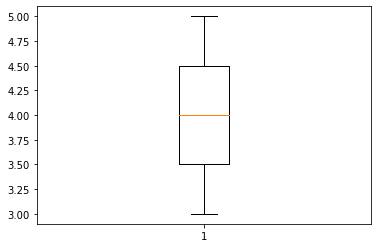

In [24]:
plt.boxplot(df['Customer_Rating'])
plt.show()

# Finding outlers of Driver Rating

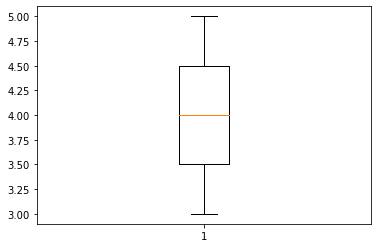

In [25]:
plt.boxplot(df['Driver_Rating'])
plt.show()

# Day wise Ride Canceled Rides by Customer

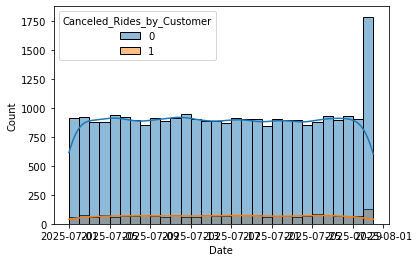

In [26]:
sns.histplot(data=df,x="Date",hue="Canceled_Rides_by_Customer",kde=True)
plt.show()

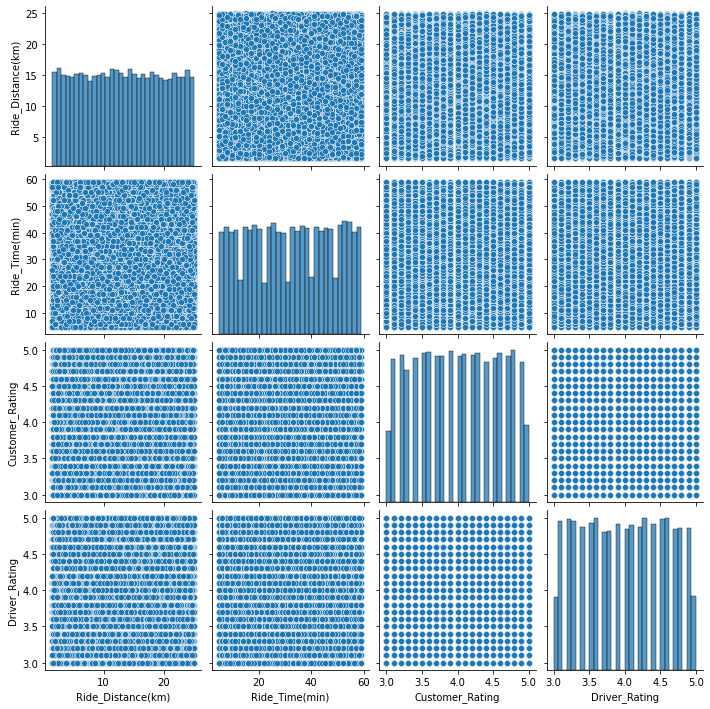

In [27]:
sns.pairplot(df[['Ride_Distance(km)', 'Ride_Time(min)', 'Customer_Rating', 'Driver_Rating']])
plt.show()

# Coorelation Matrix of Ride time ,Customer Rating, Driver Rating

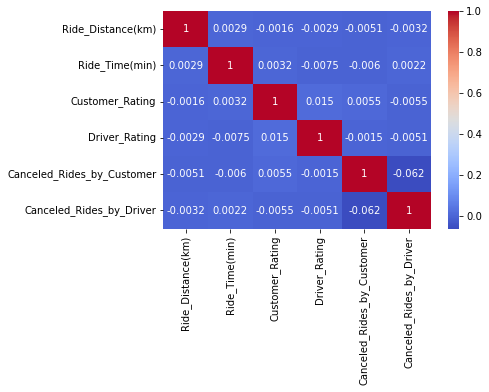

In [28]:
corr_mat = df[['Ride_Distance(km)','Ride_Time(min)','Customer_Rating','Driver_Rating',
                 'Canceled_Rides_by_Customer','Canceled_Rides_by_Driver']].corr()
sns.heatmap(corr_mat, annot=True, cmap='coolwarm')
plt.show()

# Coorelation Matrix of Data

In [29]:
corr_mat1= df.select_dtypes("number").corr()

corr_mat1

,Ride_Distance(km),Ride_Time(min),Total_Bookings,Canceled_Bookings,Customer_Rating,Canceled_Rides_by_Customer,Driver_Rating,Canceled_Rides_by_Driver
Ride_Distance(km),1.000000,0.002900,-0.009063,-0.004492,-0.001637,-0.005090,-0.002852,-0.003167
Ride_Time(min),0.002900,1.000000,-0.010516,-0.002490,0.003154,-0.006017,-0.007484,0.002205
Total_Bookings,-0.009063,-0.010516,1.000000,0.509590,-0.010581,0.001273,0.001143,0.004702
Canceled_Bookings,-0.004492,-0.002490,0.509590,1.000000,-0.012923,0.019289,-0.003947,0.010091
Customer_Rating,-0.001637,0.003154,-0.010581,-0.012923,1.000000,0.005542,0.015375,-0.005485
Canceled_Rides_by_Customer,-0.005090,-0.006017,0.001273,0.019289,0.005542,1.000000,-0.001542,-0.061944
Driver_Rating,-0.002852,-0.007484,0.001143,-0.003947,0.015375,-0.001542,1.000000,-0.005084
Canceled_Rides_by_Driver,-0.003167,0.002205,0.004702,0.010091,-0.005485,-0.061944,-0.005084,1.000000
